# Taller B3-T4 — Redes Neuronales para Forecasting
## Ventana entrada: 5 dias | Ventana salida: 5 dias

- **Parte 1 — Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 — Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [1]:
VENTANA_ENTRADA = 5   # dias de entrada
VENTANA_SALIDA  = 5   # dias de salida (promedio)


In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from utilidades.carga_datos  import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos      import construir_dense, construir_recurrente, construir_conv1d, construir_mixto
from utilidades.evaluacion   import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos     import graficar_convergencia, graficar_barras_mae

CALLBACKS = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
]


---
# PARTE 1 — Competicion
Entrenamiento y comparacion de modelos sobre log-retornos en bruto.
Metrica: MAE medio sobre los 23 activos.


## 1.1 Carga de datos

In [3]:
retornos = cargar_retornos()

X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')

X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16181, 5, 23)  |  y: (16181, 23)
Train: (13833, 5, 23)  Val: (729, 5, 23)  Test: (1619, 5, 23)


## 1.2 Baselines

In [4]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal'
)
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))


            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.005365  0.004351  0.005627         0
BuyAndHold   0.005396  0.004289  0.005581         0


## 1.3 Modelo Dense (MLP)

In [5]:
modelo_dense = construir_dense(X_train_plano.shape[1], y_train.shape[1])
modelo_dense.summary()
hist_dense = modelo_dense.fit(
    X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1
)


c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,583 (260.09 KB)

 Trainable params: 66,071 (258.09 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0209 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0059 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 6/100
214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0055 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - val_loss: 0.0043 

{'modelo': 'Dense', 'mae_train': 0.00539557285629092, 'mae_val': 0.004286962553765925, 'mae_test': 0.005621271594793874, 'n_params': 66583}


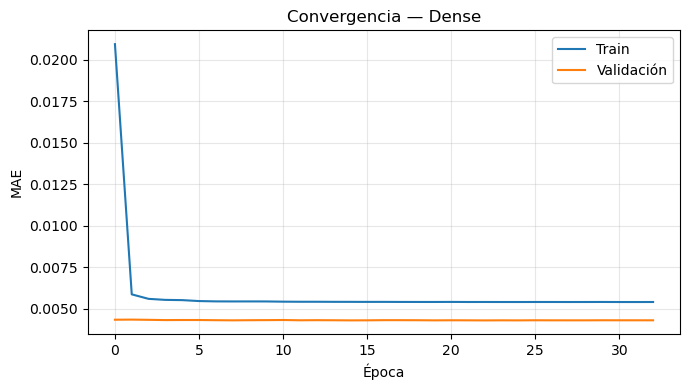

In [6]:
graficar_convergencia(hist_dense, 'Dense')
resultado_dense = evaluar_modelo(
    modelo_dense, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense'
)
print(resultado_dense)


## 1.4 Modelo Recurrente (LSTM)

In [7]:
modelo_lstm = construir_recurrente(X_train.shape[1:], y_train.shape[1])
modelo_lstm.summary()
hist_lstm = modelo_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1
)


c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,023 (93.84 KB)

 Trainable params: 24,023 (93.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0056 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0055 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0054 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0054 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/100
213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0054 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0054 - val_loss: 0.0

{'modelo': 'LSTM', 'mae_train': 0.005433656826267162, 'mae_val': 0.004378264266926256, 'mae_test': 0.005649958979245202, 'n_params': 24023}


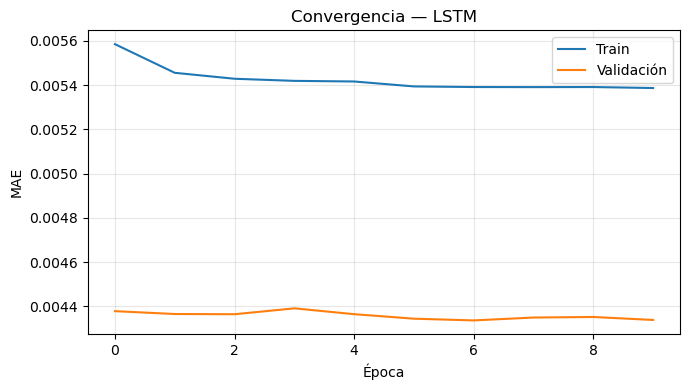

In [8]:
graficar_convergencia(hist_lstm, 'LSTM')
resultado_lstm = evaluar_modelo(
    modelo_lstm, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM'
)
print(resultado_lstm)


## 1.5 Modelo Conv1D

In [9]:
modelo_conv = construir_conv1d(X_train.shape[1:], y_train.shape[1])
modelo_conv.summary()
hist_conv = modelo_conv.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1
)


c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3, 64)          │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,415 (44.59 KB)

 Trainable params: 11,415 (44.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 5/100
210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - val_loss: 0.0

{'modelo': 'Conv1D', 'mae_train': 0.005419239673214286, 'mae_val': 0.004324030264146184, 'mae_test': 0.005613748635168893, 'n_params': 11415}


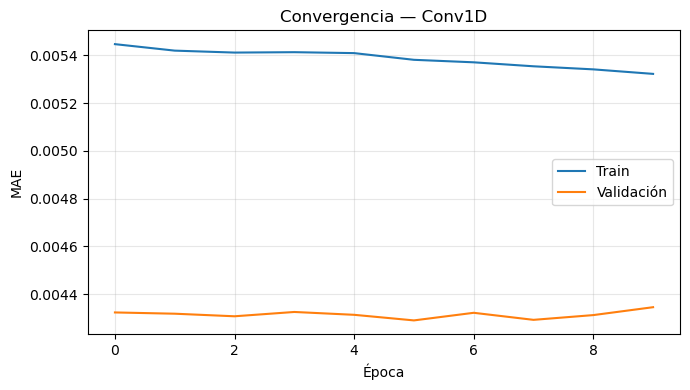

In [10]:
graficar_convergencia(hist_conv, 'Conv1D')
resultado_conv = evaluar_modelo(
    modelo_conv, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D'
)
print(resultado_conv)


## 1.6 Modelo Mixto (Conv1D + LSTM)

In [11]:
modelo_mixto = construir_mixto(X_train.shape[1:], y_train.shape[1])
modelo_mixto.summary()
hist_mixto = modelo_mixto.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1
)


Model: "Mixto"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 5, 23)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 5, 64)          │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,999 (152.34 KB)

 Trainable params: 38,999 (152.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0055 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0054 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0054 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0054 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/100
208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0054 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0053 - val_loss: 0.0044 - learning_rate: 5.0000e-04
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0053 - val_loss: 0.0043 - learning_rate: 5.0000e-04
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0052 - val_loss: 0.0

{'modelo': 'Mixto', 'mae_train': 0.005435562311822695, 'mae_val': 0.00434940583174872, 'mae_test': 0.005628345679763304, 'n_params': 38999}


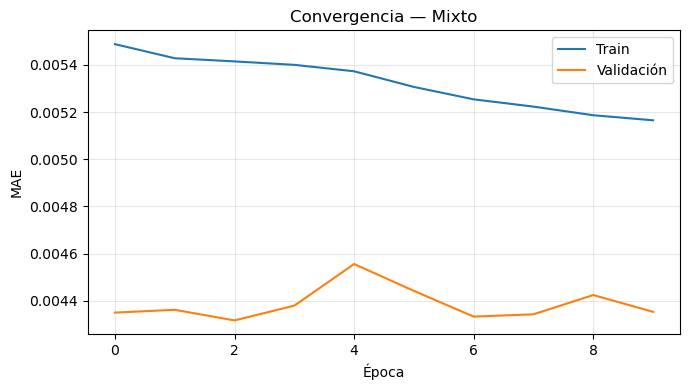

In [12]:
graficar_convergencia(hist_mixto, 'Mixto')
resultado_mixto = evaluar_modelo(
    modelo_mixto, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Mixto'
)
print(resultado_mixto)


## 1.7 Resumen de competicion y guardado

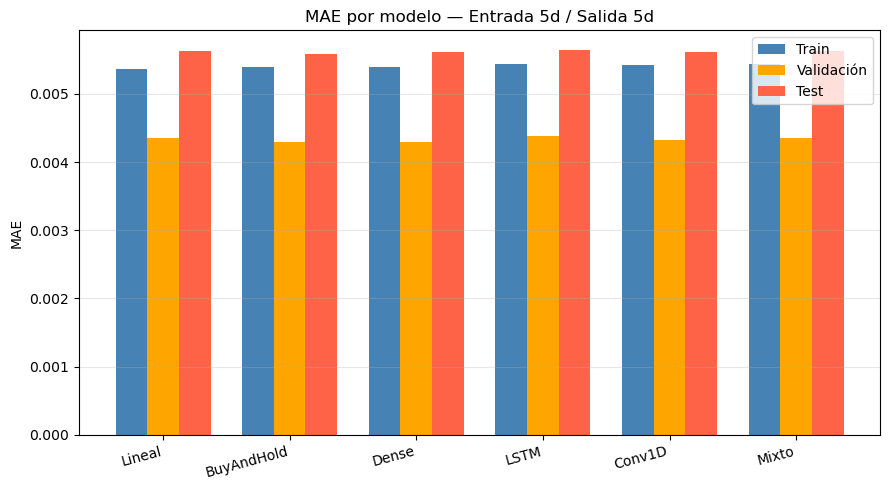

Resultados [competicion] guardados en: ../resultados/metricas/ent05_sal05.json


,mae_train,mae_val,mae_test,n_params
modelo,,,,
Lineal,0.005365,0.004351,0.005627,0
BuyAndHold,0.005396,0.004289,0.005581,0
Dense,0.005396,0.004287,0.005621,66583
LSTM,0.005434,0.004378,0.005650,24023
Conv1D,0.005419,0.004324,0.005614,11415
Mixto,0.005436,0.004349,0.005628,38999


In [13]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    resultado_dense, resultado_lstm,
    resultado_conv,  resultado_mixto,
]

graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA,
                   seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))


---
# PARTE 2 — Investigacion
Aplicacion de las tecnicas de preprocesado del Taller B3-T1 (Lopez de Prado, 2018/2020):

1. **Diferenciacion fraccional (FFD)**: encuentra el minimo `d` que hace la serie estacionaria
   conservando la mayor memoria posible. Snippets 5.3-5.4 de *Advances in Financial ML*.
2. **Denoising de la matriz de covarianza (Marchenko-Pastur)**: limpia los autovalores de ruido
   usando la distribucion teorica de Marchenko-Pastur. *Machine Learning for Asset Managers*.

Ambas tecnicas se aplican sobre los log-retornos antes de construir las ventanas temporales.
Se re-entrena el mejor modelo de la Parte 1 con los datos preprocesados y se compara el MAE.


## 2.1 Diferenciacion fraccional (FFD)
Fuente: Lopez de Prado (2018), Snippets 5.3-5.4

Busca el minimo `d` tal que la serie sea estacionaria (ADF p-value < 0.05),
preservando la maxima memoria posible respecto al precio original.


In [14]:
# ── Snippet 5.3: pesos para ventana fija (FFD) ──────────────────────────
def get_weights_ffd(d, threshold=1e-5):
    """Calcula los pesos para diferenciacion fraccional FFD."""
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k)
        k += 1
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD a una serie ────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5):
    """Aplica diferenciacion fraccional FFD a una pd.Series."""
    weights = get_weights_ffd(d, threshold)
    width = len(weights)
    result = {}
    vals = series.values
    for i in range(width - 1, len(vals)):
        result[i] = np.dot(weights, vals[i - width + 1 : i + 1])
    return pd.Series(result, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Devuelve (d_optimo, serie_diferenciada).
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    for d in d_values:
        serie_diff = frac_diff_ffd(serie, d, threshold)
        adf_pval = adfuller(serie_diff.dropna(), autolag='AIC')[1]
        if adf_pval < pvalue:
            return d, serie_diff
    # Si ninguno logra estacionariedad, devolver d=1 (diferencia entera)
    return 1.0, frac_diff_ffd(serie, 1.0, threshold)


In [15]:
# Aplicar FFD a cada uno de los 23 activos
# Usamos los log-precios (no retornos) como entrada a la FFD,
# igual que en el Taller B3-T1
precios_log = np.log(retornos.cumsum() + 1)  # reconstruir log-precio desde retornos

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in precios_log.columns:
    d_opt, serie_ffd = encontrar_d_minimo(precios_log[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

# Visualizar distribucion de d optimos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
# Comparar estacionariedad: original vs FFD para un activo de ejemplo
ticker_ej = precios_log.columns[0]
axes[1].plot(precios_log[ticker_ej].values[:500], label='Log-precio original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500], label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-precio vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


c:\Users\1jose\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


ValueError: zero-size array to reduction operation maximum which has no identity

## 2.2 Denoising de la matriz de covarianza (Marchenko-Pastur)
Fuente: Lopez de Prado (2020), *Machine Learning for Asset Managers*

Ajusta la distribucion de Marchenko-Pastur a los autovalores empiricos,
identifica autovalores de ruido y los sustituye por su media.
Luego se usa la correlacion limpia para reescalar los retornos.


In [ ]:
def mp_pdf(var, q, pts=1000):
    """PDF teorica de Marchenko-Pastur."""
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=0.25, x=None):
    """KDE sobre observaciones."""
    obs2 = obs.reshape(-1, 1)
    kde = KernelDensity(bandwidth=bwidth).fit(obs2)
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    log_prob = kde.score_samples(x.reshape(-1, 1))
    return x, np.exp(log_prob)

def err_pdfs(var, evals, q, bwidth=0.01):
    """SSE entre KDE empirica y PDF de Marchenko-Pastur."""
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, bwidth, x=x_mp)
    return np.sum((pdf_kde - pdf_mp) ** 2)

def find_max_eval(evals, q, bwidth=0.01):
    """Encuentra sigma^2 optimo y retorna lambda_max correspondiente."""
    res = minimize_scalar(err_pdfs, bounds=(1e-5, 1 - 1e-5), method='bounded',
                          args=(evals, q, bwidth))
    var_opt = res.x if res.success else 1.0
    _, _, lmax = mp_pdf(var_opt, q)
    return var_opt, lmax

def denoised_corr(evals, evecs, n_signal):
    """Reconstruye la matriz de correlacion con autovalores de ruido igualados a su media."""
    ev = evals.copy()
    ev[n_signal:] = ev[n_signal:].mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    # Normalizar diagonal a 1
    d = np.sqrt(np.diag(corr))
    corr = corr / np.outer(d, d)
    return corr

def aplicar_denoising(returns_df):
    """
    Aplica denoising Marchenko-Pastur a una matriz de retornos.
    Devuelve los retornos reescalados con la correlacion limpia.
    """
    T, N = returns_df.shape
    q = T / N

    cov = returns_df.cov().values
    std = np.sqrt(np.diag(cov))
    # Convertir a correlacion
    corr = cov / np.outer(std, std)
    corr = np.clip(corr, -1, 1)
    np.fill_diagonal(corr, 1)

    evals, evecs = np.linalg.eigh(corr)
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]

    var_opt, lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = int(np.sum(evals > lmax))
    n_signal = max(1, n_signal)  # al menos 1 componente de senyal

    corr_clean = denoised_corr(evals, evecs, n_signal)

    # Reconstruir covarianza limpia y reescalar retornos
    cov_clean = corr_clean * np.outer(std, std)
    # Transformacion: X_clean = X @ L^{-1/2} donde L = chol(cov_clean)
    try:
        L = np.linalg.cholesky(cov_clean + 1e-8 * np.eye(N))
        L_inv = np.linalg.inv(L)
        returns_clean = returns_df.values @ L_inv.T
    except np.linalg.LinAlgError:
        returns_clean = returns_df.values  # fallback: sin transformacion

    return pd.DataFrame(returns_clean, index=returns_df.index,
                        columns=returns_df.columns), n_signal, lmax


In [ ]:
# Aplicar denoising sobre los retornos FFD
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de señal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

# Visualizar autovalores antes y despues
T, N = df_ffd.shape
evals_raw = np.sort(np.linalg.eigvalsh(df_ffd.corr().values))[::-1]
evals_clean = np.sort(np.linalg.eigvalsh(df_ffd_denoised.corr().values))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7, label='Original')
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising')
axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange',    alpha=0.7, label='Denoised')
axes[1].set_title('Autovalores — despues del denoising')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados
Se aplica StandardScaler (ajustado solo sobre train) para normalizar
la escala tras la transformacion FFD + denoising.


In [ ]:
# Alinear indices: FFD puede acortar la serie
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')

X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)

# StandardScaler ajustado solo sobre train (evitar data leakage)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))

X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)

print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado


In [ ]:
df_comp = pd.DataFrame(resultados_competicion)
mejor_nombre = df_comp.loc[df_comp['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1: {mejor_nombre}')

usa_plano = mejor_nombre in ('Dense', 'Lineal')

constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Lineal': lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1], neuronas=(64,)),
}

modelo_prep = constructores_prep.get(mejor_nombre, constructores_prep['Dense'])()

X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d

hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1
)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')

resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep'
)
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado


In [ ]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()

comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto del preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')

guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA,
                   seccion='investigacion')
